In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
pio.templates['plotly'].layout['autosize'] = False

#### Loading the data

In [3]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') # IBM sample data available at https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

#### Checking data types, number of columns, dropping customer ID

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.dtypes # to do, assign float64 type to TotalCharges column -- ok

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
len(df["customerID"].unique())

7043

In [8]:
df.shape

(7043, 21)

In [9]:
df=df.drop(columns=['customerID'])

#### Summary:
- Raw data: 7043 rows, 21 columns, of which 19 are features. The remainder: customer ID and target variable (churn)

- Done: Dropped customer ID

- To do: 1. Correct data type: TotalCharges is currently object, should be float.
         2. Map Senior Citizen values from 0/1 to No/Yes for exploratory data analysis

#### Checking for null and empty strings, correcting data type

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [11]:
df.isna().sum(axis=0)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df[df['TotalCharges'].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
df[df['tenure']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [14]:
df=df.dropna(ignore_index=True)

In [15]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [17]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [18]:
df.shape

(7032, 20)

In [19]:
df.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

#### Summary:
- Done: Removed 11 rows that corresponded to customers that subscribed this month. Corrected Total Charges data type. Mapped Senior Citizen from 0/1 to No/Yes.

- No other invalid values found

- Final dataset: 7032 rows, 20 columns (including target)

#### Initial Analysis

##### Numerical features histograms

In [20]:
numerical_features = [col for col in df.columns if df[col].dtypes != 'object']

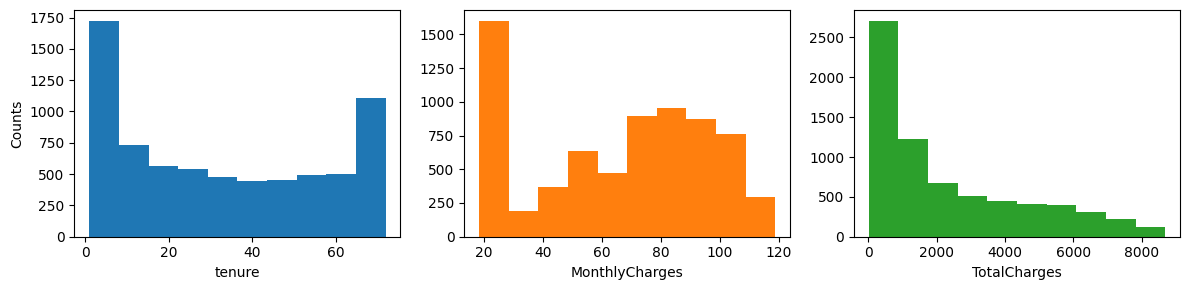

In [21]:
c = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].hist(df[numerical_features[i]], color = c[i],bins=10)
    axs[i].set_xlabel(numerical_features[i])

    #other option:
    #counts, bins = np.histogram(df[numerical_features[i]],bins=10)
    #axs[i].stairs(counts, bins, color = 'black')
axs[0].set_ylabel('Counts')
plt.tight_layout()

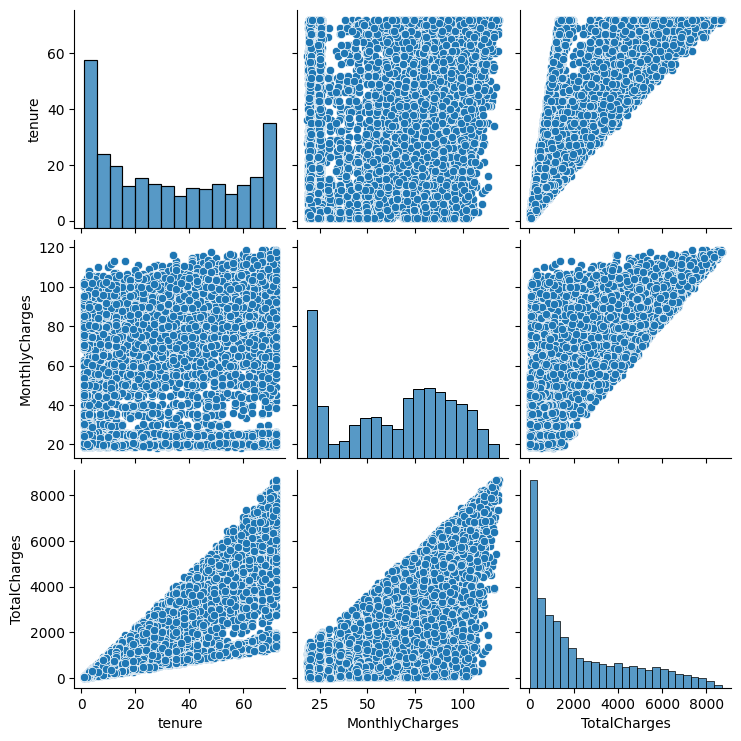

In [22]:
sns.pairplot(df[numerical_features]);

##### Categorical features pie charts

In [23]:
categorical_features = [col for col in df.columns if (df[col].dtypes == 'object' and col != 'Churn')]

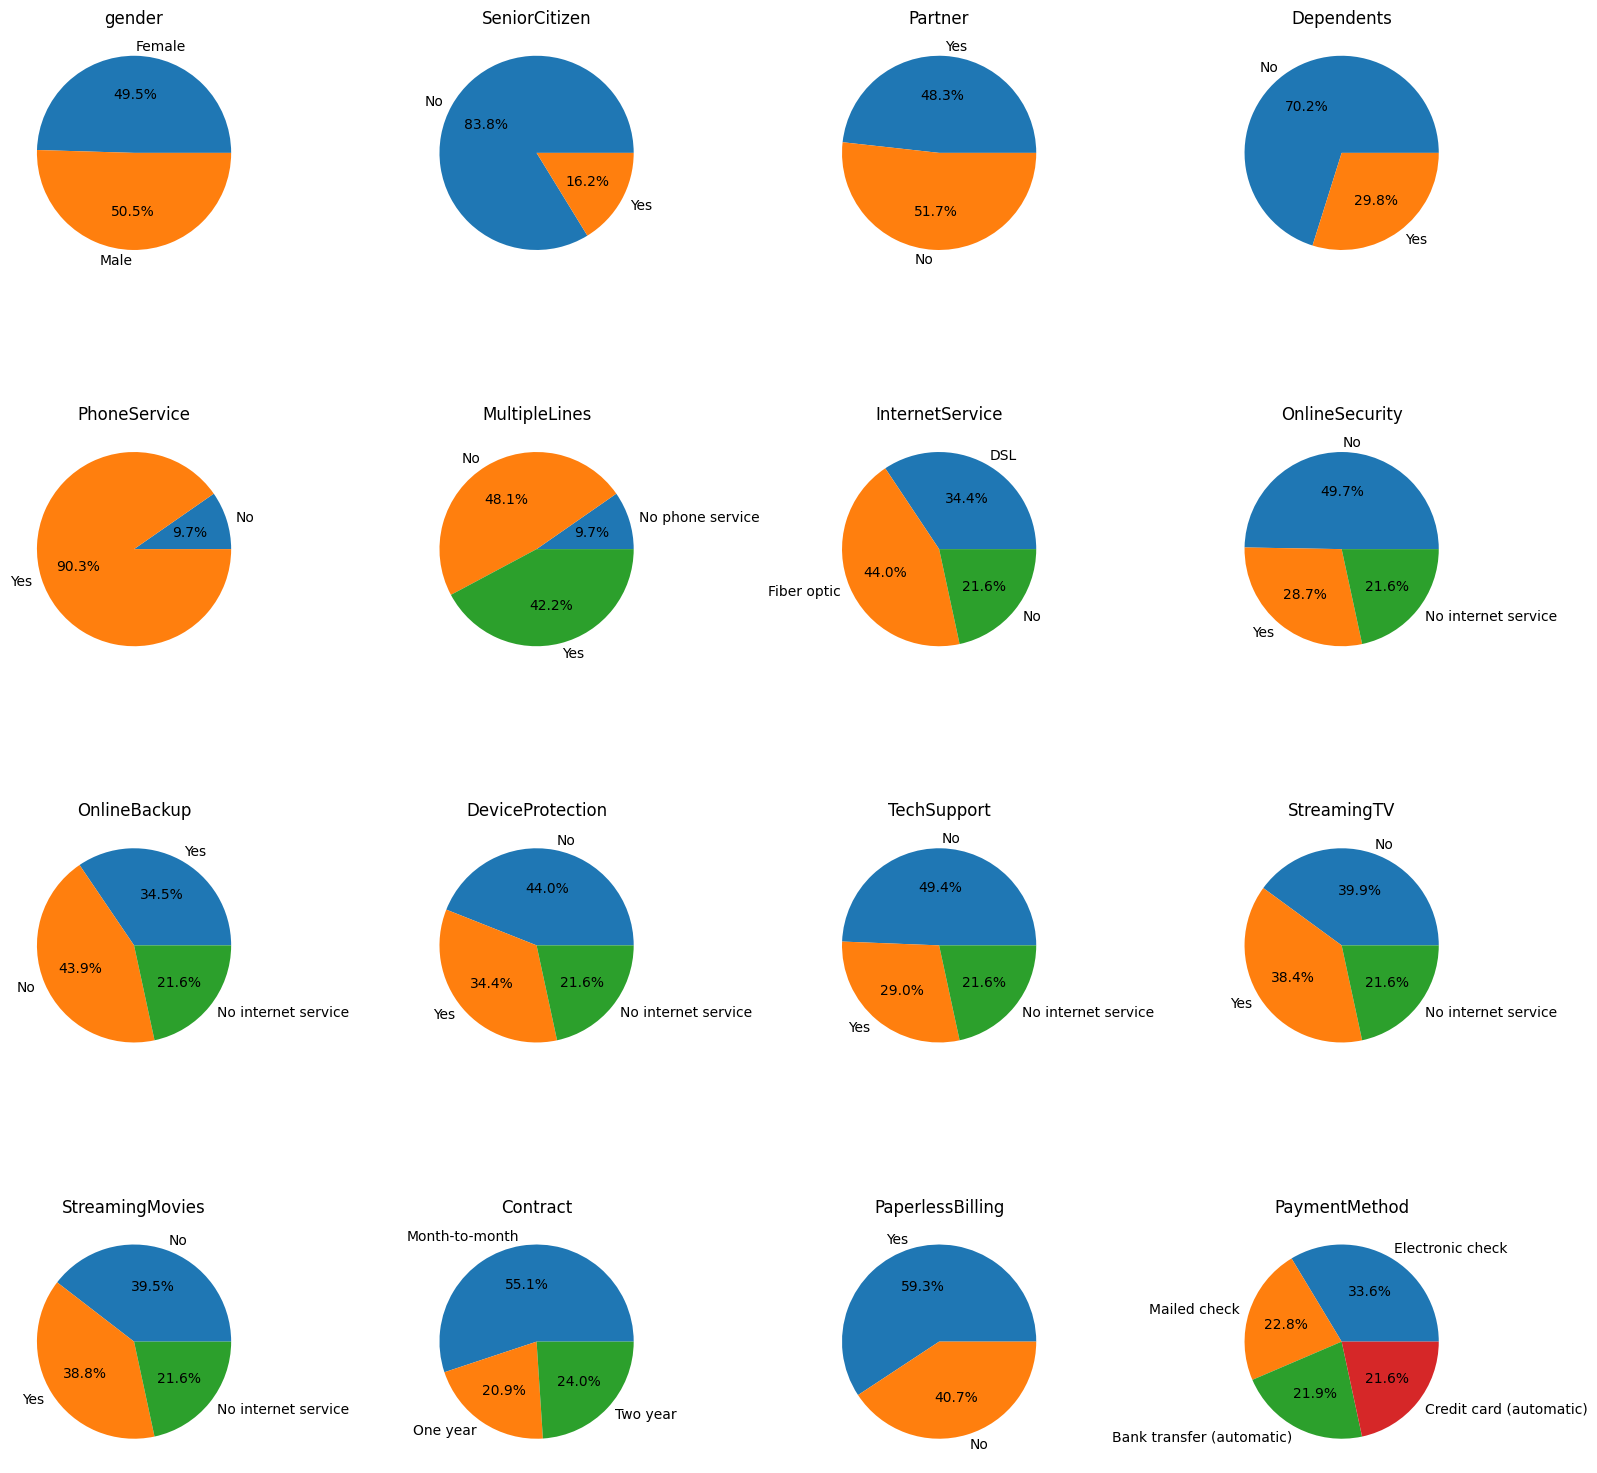

In [24]:
fig, axs = plt.subplots(4,4, figsize = (16,16))
k=0
l=0
for col in categorical_features:
    labels = df[col].unique()
    sizes = [(df[col] == labels[j]).sum() for j in range(len(labels))]

    #other option:
    #labels = df[col].value_counts().index
    #sizes = df[col].value_counts().values
    
    axs[k,l].pie(sizes, labels = labels, autopct='%1.1f%%', colors = c)
    axs[k,l].set_title(col)
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1
        
plt.tight_layout()

In [25]:
# below analysis only captures linear correlation. Not well suited for categories

In [26]:
pd.get_dummies(df).corr()["Churn_Yes"].sort_values() 

Churn_No                                  -1.000000
tenure                                    -0.354049
Contract_Two year                         -0.301552
OnlineBackup_No internet service          -0.227578
DeviceProtection_No internet service      -0.227578
InternetService_No                        -0.227578
OnlineSecurity_No internet service        -0.227578
TechSupport_No internet service           -0.227578
StreamingTV_No internet service           -0.227578
StreamingMovies_No internet service       -0.227578
TotalCharges                              -0.199484
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
SeniorCitizen_No                          -0.150541
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetServ

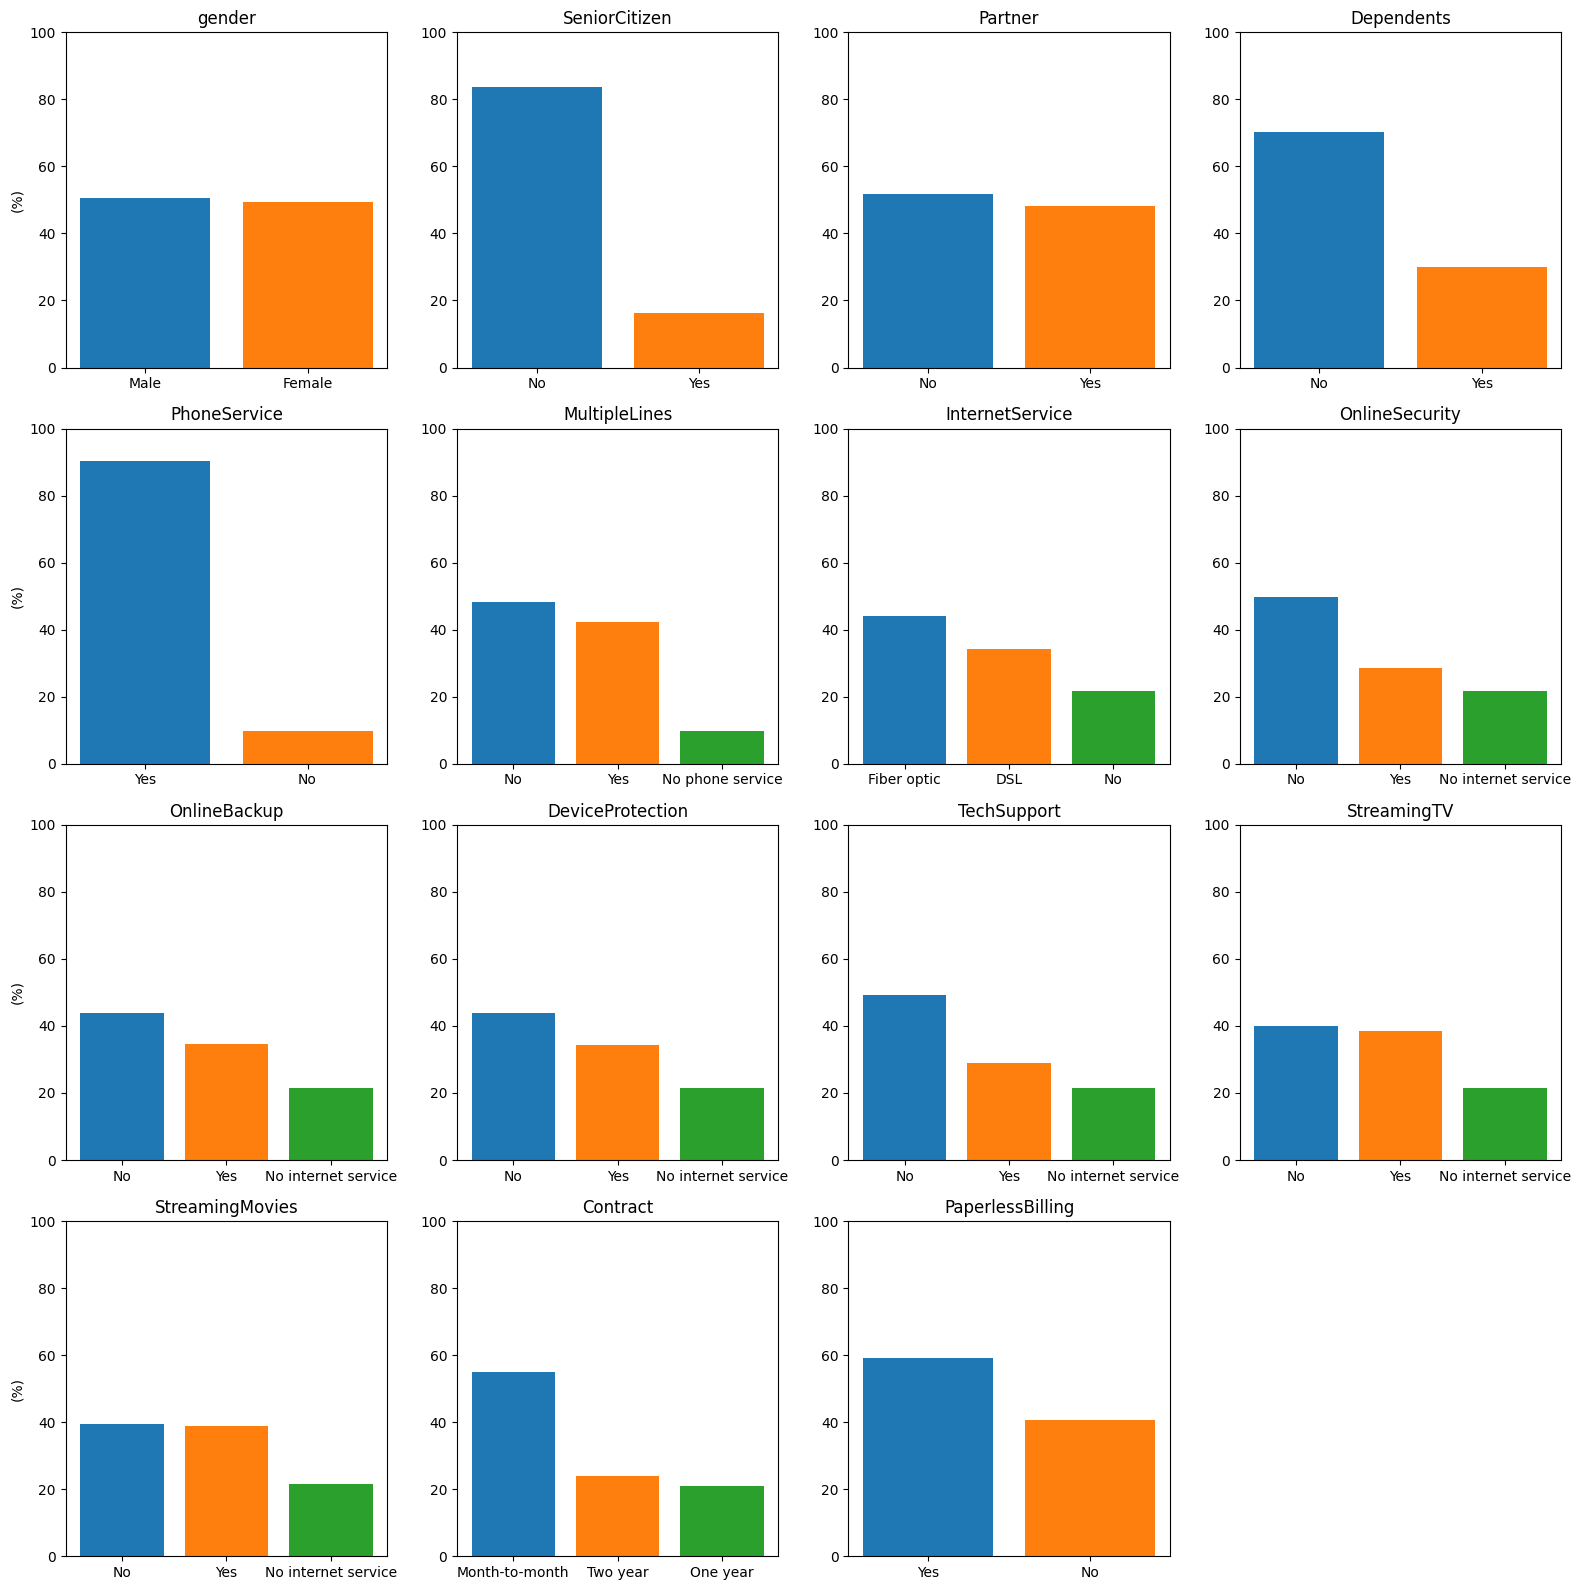

In [27]:
fig, axs = plt.subplots(4,4, figsize = (16,16))
k=0
l=0
for col in categorical_features[:-1]:
    counts = df[col].value_counts(normalize=True) * 100

    axs[k,l].bar(counts.index, counts.values, color = c)
    axs[k,l].set_title(col)
    axs[k,l].set_ylim(0, 100)

    if l==0:
        axs[k,l].set_ylabel('(%)')
    else: 
        pass
    
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1

axs[k,l].set_axis_off()
plt.tight_layout()

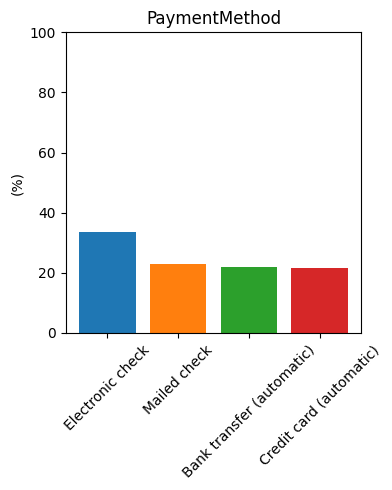

In [28]:
fig, ax = plt.subplots(1,1, figsize = (4,5))

for col in categorical_features[-1:]:
    counts = df[col].value_counts(normalize=True) * 100

    ax.bar(counts.index, counts.values, color = c)
    ax.set_title(col)
    ax.set_ylim(0, 100)
    ax.set_ylabel('(%)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

##### Numerical features histograms w churn

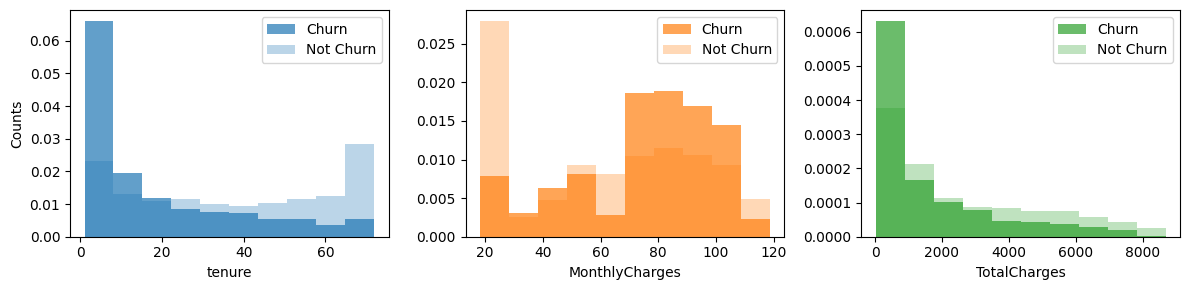

In [29]:
c = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    bins = np.histogram(df[numerical_features[i]], bins = 10)[1]
    axs[i].hist(df[df['Churn'] == 'Yes'][numerical_features[i]], color = c[i], alpha = 0.7, bins = bins, label = 'Churn', density=True)
    axs[i].hist(df[df['Churn'] == 'No'][numerical_features[i]], color = c[i], alpha = 0.3, bins = bins, label = 'Not Churn', density=True)
    axs[i].set_xlabel(numerical_features[i])
    axs[i].legend()
axs[0].set_ylabel('Counts')
plt.tight_layout()

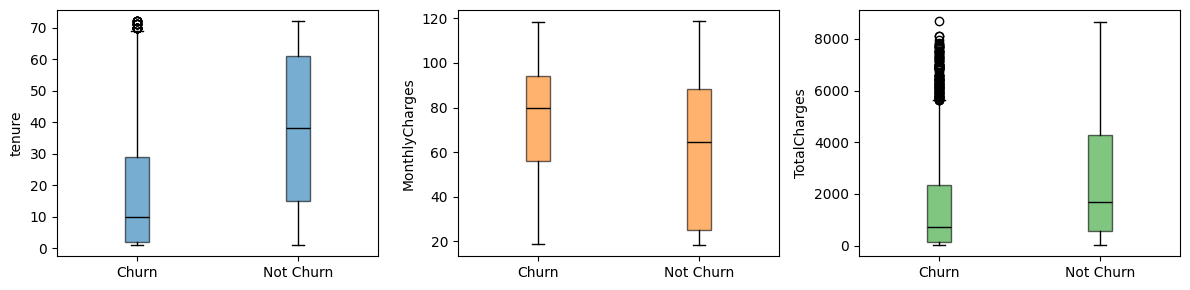

In [30]:
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].boxplot([df[df['Churn']=='Yes'][numerical_features[i]],df[df['Churn']=='No'][numerical_features[i]]],
                   patch_artist=True, 
                   boxprops={'facecolor': c[i], 'alpha' : 0.6},
                   medianprops={'color': 'black'})
    axs[i].set_ylabel(numerical_features[i])
    axs[i].set_xticks([y + 1 for y in range(2)], labels=['Churn', 'Not Churn'])
plt.tight_layout()

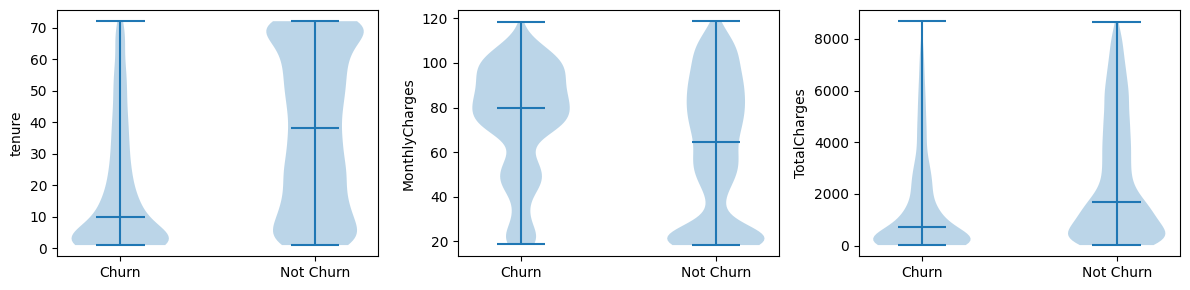

In [31]:
fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
for i in range(len(numerical_features)):
    axs[i].violinplot([df[df['Churn']=='Yes'][numerical_features[i]],df[df['Churn']=='No'][numerical_features[i]]],showmeans=False,showmedians=True)
    axs[i].set_ylabel(numerical_features[i])
    axs[i].set_xticks([y + 1 for y in range(2)], labels=['Churn', 'Not Churn'])
plt.tight_layout()

##### Categorical features pie charts w churn

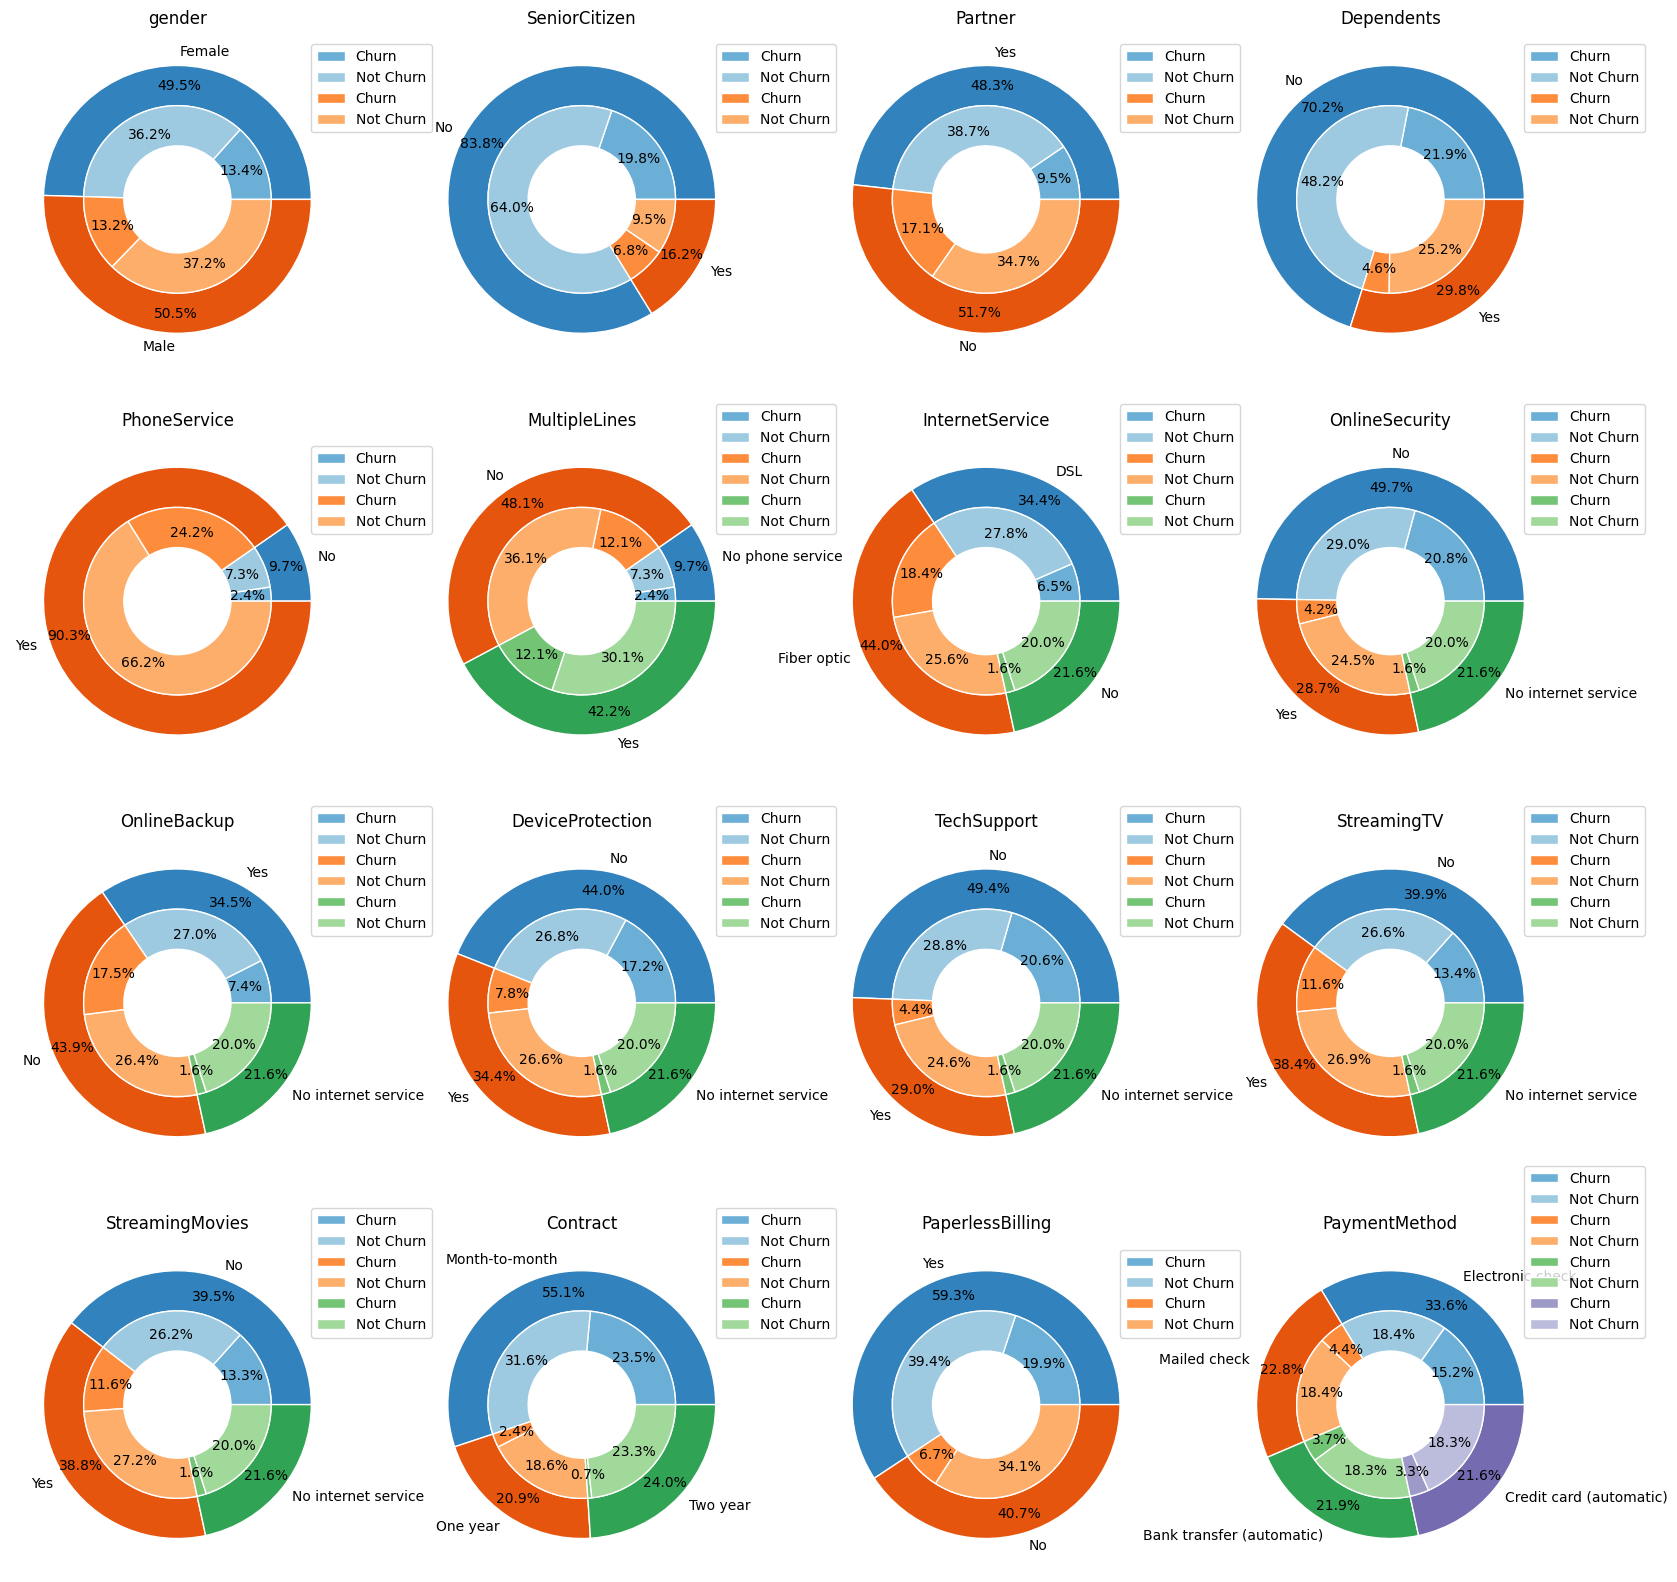

In [32]:
tab20c = plt.color_sequences["tab20c"]
outer_colors = [tab20c[i] for i in [0, 4, 8, 12]]
inner_colors = [tab20c[i] for i in [1, 2, 5, 6, 9, 10, 13, 14]]

fig, axs = plt.subplots(4,4, figsize = (20,20))
k=0
l=0

for col in categorical_features:
    width = 0.3
    group_labels = df[col].unique()
    vals = np.array([[((df[col] == group_labels[j]) & (df['Churn'] == 'Yes')).sum(), ((df[col] == group_labels[j]) & (df['Churn'] == 'No')).sum()] for j in range(len(group_labels))])

    axs[k,l].pie(vals.sum(axis=1), radius=1, colors=outer_colors,
       wedgeprops=dict(width=width, edgecolor='w'), labels = group_labels, autopct='%1.1f%%', pctdistance=0.85)
    axs[k,l].pie(vals.flatten(), radius=1-width, colors=inner_colors,
       wedgeprops=dict(width=width, edgecolor='w'), labels = ['Churn', 'Not Churn']*len(group_labels), labeldistance=None, autopct='%1.1f%%', pctdistance=0.75)

    axs[k,l].set(aspect="equal", title=col)
    handles, labels = axs[k,l].get_legend_handles_labels()
    
    if col == 'Payment Method':
        axs[k,l].legend(handles[len(group_labels):], ['Churn', 'Not Churn']*len(group_labels), loc=(0.9, 0.3)) 
    else:
        axs[k,l].legend(handles[len(group_labels):], ['Churn', 'Not Churn']*len(group_labels), loc=(0.9, 0.7))
    
    if l == 3:
        l = 0
        k += 1
    else:
        l += 1

axs[3,3].set_axis_off()
plt.show()

#### Summary:
- Done: Histograms, box plots, violin plots, bar charts and pie charts for each feature

#### Customers Statistics

##### Numerical features correlation analysis

In [33]:
df[["tenure","MonthlyCharges","TotalCharges"]].corr()    # Monthly Charges and total charges are highly correlated, as expected

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


##### Customers with phone service AND internet Service

In [34]:
print(f"Percentage of total customers: {len(df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")])/len(df)*100:.2f}%")

Percentage of total customers: 68.71%


##### Customers with phone service

In [35]:
print(f"Percentage of total customers: {len(df[(df["PhoneService"]=="Yes")])/len(df)*100:.2f}%")

Percentage of total customers: 90.33%


##### Customers with internet service

In [36]:
print(f"Percentage of total customers: {len(df[df["InternetService"]!="No"])/len(df)*100:.2f}%")

Percentage of total customers: 78.38%


##### Customers with ONLY phone service

In [37]:
print(f"Percentage of total customers: {len(df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")])/len(df)*100:.2f}%")

Percentage of total customers: 21.62%


In [38]:
len(df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")])

1520

##### Customers with ONLY internet service

In [39]:
print(f"Percentage of total customers: {len(df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")])/len(df)*100:.2f}%")

Percentage of total customers: 9.67%


In [40]:
len(df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")])

680

##### Summary:
- 21.62% of total customers only have phone service 

- 9.67% of total customers only have internet service 

- 68.71% of total customers have both internet and phone service

------------------------------------------------------------

- 90.33% of total customers have phone service

- 78.38% of total customers have internet service

##### Current month revenue

In [41]:
month_revenue=df["MonthlyCharges"].sum() 
print(f"Month revenue: ${month_revenue:,.2f}")

Month revenue: $455,661.00


In [42]:
print(f"Average month charge: ${df["MonthlyCharges"].mean():,.2f}") 

Average month charge: $64.80


##### Revenue phone service AND internet service

In [43]:
print(f"Month revenue phone service AND internet service: \
${df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].sum():,.2f} \
({df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()*100/month_revenue:,.2f}%)")

Month revenue phone service AND internet service: $395,070.15 (86.70%)


In [44]:
print(f"Average month charge phone service AND internet service: ${df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].mean():,.2f}") 

Average month charge phone service AND internet service: $81.76


##### Revenue ONLY phone service

In [45]:
print(f"Month revenue ONLY phone service: \
${df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].sum():,.2f} \
({df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].sum()*100/month_revenue:,.2f}%)")

Month revenue ONLY phone service: $32,035.95 (7.03%)


In [46]:
print(f"Average month charge ONLY phone service: ${df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].mean():,.2f}") 

Average month charge ONLY phone service: $21.08


In [47]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["tenure"].mean()

np.float64(30.667763157894736)

In [48]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["tenure"].median()

np.float64(25.0)

##### Revenue ONLY internet service

In [49]:
print(f"Month revenue ONLY internet service: \
${df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].sum():,.2f} \
({df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()*100/month_revenue:,.2f}%)")

Month revenue ONLY internet service: $28,554.90 (6.27%)


In [50]:
print(f"Average month charge ONLY internet service: ${df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].mean():,.2f}") 

Average month charge ONLY internet service: $41.99


In [51]:
df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["tenure"].mean()

np.float64(31.830882352941178)

In [52]:
df[(df["PhoneService"]=="No") & (df["InternetService"]!="No")]["tenure"].median()

np.float64(29.0)

##### Summary:
- Current month revenue: \\$455 661.00 (average per customer: \\$64.80)

Revenue contribution by service type:

- Current month phone service AND internet service revenue: \\$ 395 070.15 (86.70\% of total revenue) (average per customer: \\$81.76)

- Current month ONLY phone service revenue: \\$ 32 035.95  (7.03\% of total revenue) (average per customer: \\$21.08)

- Current month ONLY internet service revenue: \\$ 28 554.90  (6.27\% of total revenue) (average per customer: \\$41.99)

##### Lost revenue

In [53]:
lost_revenue=df[df["Churn"]=="Yes"]["MonthlyCharges"].sum() 
print(f"Lost month revenue: ${lost_revenue:,.2f}")

Lost month revenue: $139,130.85


In [54]:
print(f"Lost average month charge: ${df[df["Churn"]=="Yes"]["MonthlyCharges"].mean():,.2f}") 

Lost average month charge: $74.44


In [55]:
df[df["Churn"]=="No"]["MonthlyCharges"].mean()

np.float64(61.307408483439865)

In [56]:
df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()/df["MonthlyCharges"].sum()   # The churned contracts represent 30% of this month revenue. Since around 26% of customers churned, we already expected their monthly charges to be higher than the average

np.float64(0.30533850823309433)

##### Lost revenue phone service AND internet service

In [57]:
print(f"Lost month revenue phone service AND internet service: \
${df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].sum():,.2f} \
({df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()*100/lost_revenue:,.2f}%)")

Lost month revenue phone service AND internet service: $130,448.50 (93.76%)


In [58]:
print(f"Lost average month charge phone service AND internet service: ${df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["MonthlyCharges"].mean():,.2f}") 

Lost average month charge phone service AND internet service: $82.25


##### Lost revenue ONLY phone service

In [59]:
print(f"Lost month revenue ONLY phone service: \
${df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].sum():,.2f} \
({df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].sum()*100/lost_revenue:,.2f}%)")

Lost month revenue ONLY phone service: $2,301.60 (1.65%)


In [60]:
print(f"Lost average month charge ONLY phone service: ${df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")]["MonthlyCharges"].mean():,.2f}") 

Lost average month charge ONLY phone service: $20.37


##### Lost revenue ONLY internet service

In [61]:
print(f"Lost month revenue ONLY internet service: \
${df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].sum():,.2f} \
({df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].sum()*100/lost_revenue:,.2f}%)")

Lost month revenue ONLY internet service: $6,380.75 (4.59%)


In [62]:
print(f"Lost average month charge ONLY internet service: ${df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")]["MonthlyCharges"].mean():,.2f}") 

Lost average month charge ONLY internet service: $37.53


##### Summary:
- Total lost revenue due to churn: \\$139 130.85 (average per churned customer: $74.44)

Revenue loss by service type:

- Lost revenue phone service AND internet service: \\$130 448.50 (93.76\% of total revenue lost) (average per customer: $82.25)

- Lost revenue ONLY phone service: \\$ 2 301.60 (1.65\% of total revenue lost) (average per customer: $20.37)

- Lost revenue ONLY internet service: \\$ 6 380.75 (4.59\% of total revenue lost) (average per customer: $37.53)

##### Total churned customers

In [63]:
churned_customers=len(df[df["Churn"]=="Yes"].index)
print(f"Total churned customers: {churned_customers}")

Total churned customers: 1869


##### Churned customers with phone service AND internet service

In [64]:
print(f"Churned customers with phone service AND internet service: \
{len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")])} \
({len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]!="No")])*100/churned_customers:.2f}%)")

Churned customers with phone service AND internet service: 1586 (84.86%)


In [65]:
df[(df["PhoneService"]=="Yes") & (df["InternetService"]!="No")]["Churn"].value_counts(normalize=True)*100

Churn
No     67.177152
Yes    32.822848
Name: proportion, dtype: float64

##### Churned customers with ONLY phone service

In [66]:
print(f"Churned customers with ONLY phone service: \
{len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")])} \
({len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="Yes") & (df["InternetService"]=="No")])*100/churned_customers:.2f}%)")

Churned customers with ONLY phone service: 113 (6.05%)


##### Churned customers with ONLY internet service

In [67]:
print(f"Churned customers with ONLY internet service: \
{len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")])} \
({len(df[(df["Churn"]=="Yes") & (df["PhoneService"]=="No") & (df["InternetService"]!="No")])*100/churned_customers:.2f}%)")

Churned customers with ONLY internet service: 170 (9.10%)


##### Summary:
- Total number of churned customers: 1869

Breakdown by service type:

- Number of churned customers with ONLY phone service: 113 (6.05% of churned customers)

- Number of churned customers with ONLY internet service: 170 (9.10% of churned customers)

- Number of churned customers with phone service and internet service: 1586 (84.86% of churned customers)

We saw previously that 68.71% of customers have both internet and phone services. This group represents 84.86% of all churned customers and accounts for 93.76% of revenue lost due to churn. Additionally, 32.8% of customers in this segment churned, which is higher than the overall churn rate across the entire customer population.

Let's take a closer look at this subgroup characteristics in the Risk Analysis Notebooks.

#### Tenure categories

In [68]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

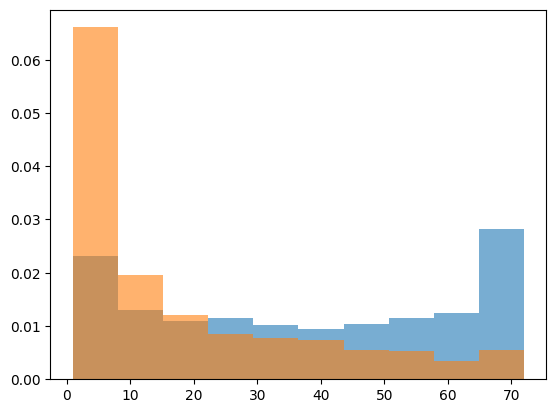

In [69]:
counts, bins=np.histogram(df["tenure"],bins=10)
plt.hist(df[df["Churn"]=="No"]["tenure"],density=True,alpha=0.6,bins=bins)
plt.hist(df[df["Churn"]=="Yes"]["tenure"],density=True,alpha=0.6,bins=bins);

Possible customer tenure levels:
    
- over 48 months: customer level 4 (senior customer)

- between 36 and 48 months: customer level 3

- between 24 and 36 months: customer level 2

- between 12 and 24 months: customer level 1   

- less than 12 months: customer level 0 (new customer)

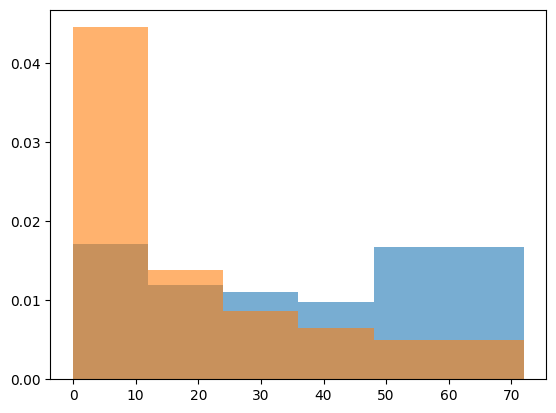

In [70]:
bins=[0,12,24,36,48,72]
plt.hist(df[df["Churn"]=="No"]["tenure"],density=True,alpha=0.6,bins=bins)
plt.hist(df[df["Churn"]=="Yes"]["tenure"],density=True,alpha=0.6,bins=bins);

In [71]:
cust_level=[]
for i in range(len(df)):
    if df.loc[i,"tenure"]<12:
        cust_level.append(0)
    elif df.loc[i,"tenure"]<24:
        cust_level.append(1)
    elif df.loc[i,"tenure"]<36:
        cust_level.append(2)
    elif df.loc[i,"tenure"]<48:
        cust_level.append(3)
    else:
        cust_level.append(4)

In [72]:
df["CustomerLevel"]=cust_level

In [73]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerLevel
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0


In [74]:
df_grouped=df.groupby(["Churn","CustomerLevel"]).size().reset_index().rename(columns={0:"counts"})
df_grouped.head()

,Churn,CustomerLevel,counts
0,No,0,1059
1,No,1,738
2,No,2,683
3,No,3,602
4,No,4,2081


In [75]:
total_counts={}
for val in df_grouped["CustomerLevel"].unique():
    total_counts[val]=df_grouped[df_grouped["CustomerLevel"]==val]["counts"].sum()

In [76]:
for i in range(len(df_grouped)):
    df_grouped.loc[i,"percent_text"]=str(round(100*df_grouped.loc[i,"counts"]/total_counts[df_grouped["CustomerLevel"][i]],1))+"%"
    df_grouped.loc[i,"%"]=100*df_grouped.loc[i,"counts"]/total_counts[df_grouped["CustomerLevel"][i]]

In [77]:
# y-axis : counts. The below percent visualization maybe better due to the percent values show on top of the bars, but this counts representantion shows how the customers are distributed along the seniority levels.
fig = px.bar(df_grouped, x="CustomerLevel", y="counts",color="Churn", text="percent_text", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [78]:
# y-axis : percent. This representation causes less awkwardness due to the percents, but does not offer info on the number of customers per seniority level.
fig = px.bar(df_grouped, x="CustomerLevel", y="%",color="Churn", text="percent_text", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [79]:
# other option to obtain the same results
pd.crosstab(df["Churn"],df["CustomerLevel"],normalize='columns')*100

CustomerLevel,0,1,2,3,4
Churn,,,,,
No,51.457726,70.487106,77.968037,80.481283,90.360399
Yes,48.542274,29.512894,22.031963,19.518717,9.639601


In [80]:
print(f"Level 0 and 1 customers: {df[df["CustomerLevel"].isin([0,1])]["Churn"].value_counts().sum()} \
(of which {df[df["CustomerLevel"].isin([0,1])]["Churn"].value_counts(normalize=True)["Yes"]*100:,.2f}% are churners)")

Level 0 and 1 customers: 3105 (of which 42.13% are churners)


In [81]:
print(f"Percentage of total customers: {len(df[df["CustomerLevel"].isin([0,1])])/len(df)*100:.2f}%")

Percentage of total customers: 44.16%


In [82]:
print(f"Level 2, 3 and 4 customers: {df[df["CustomerLevel"].isin([2,3,4])]["Churn"].value_counts().sum()} \
(of which {df[df["CustomerLevel"].isin([2,3,4])]["Churn"].value_counts(normalize=True)["Yes"]*100:,.2f}% are churners)")

Level 2, 3 and 4 customers: 3927 (of which 14.29% are churners)


#### Summary:
Possible risk group with 42.13% churn rate: customers level 0 and 1, formed of 3105 customers (44.2% of total customers).

### Other tests

#### Boxplot per Categorical Feature

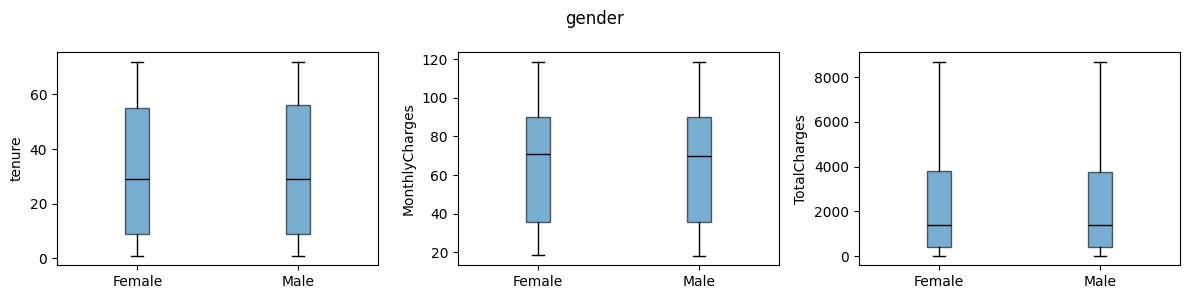

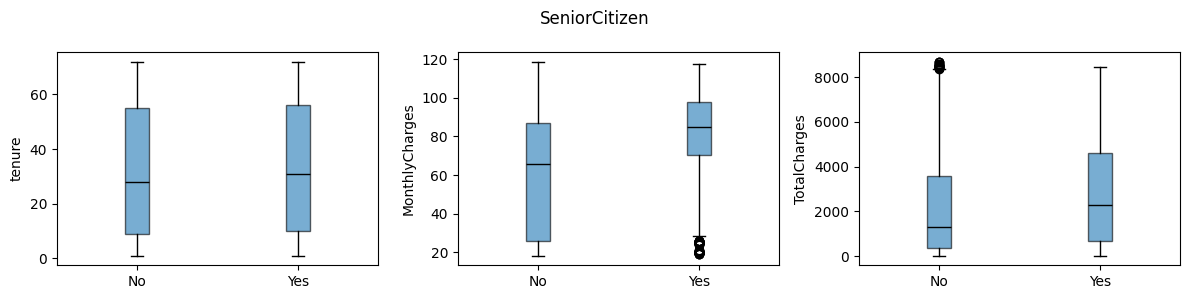

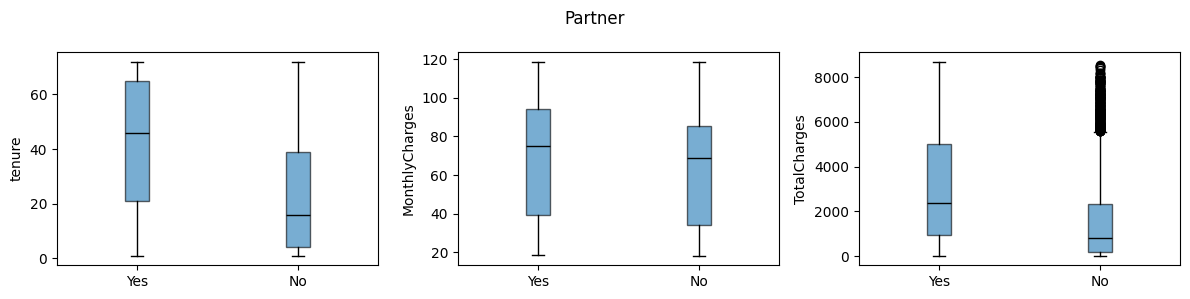

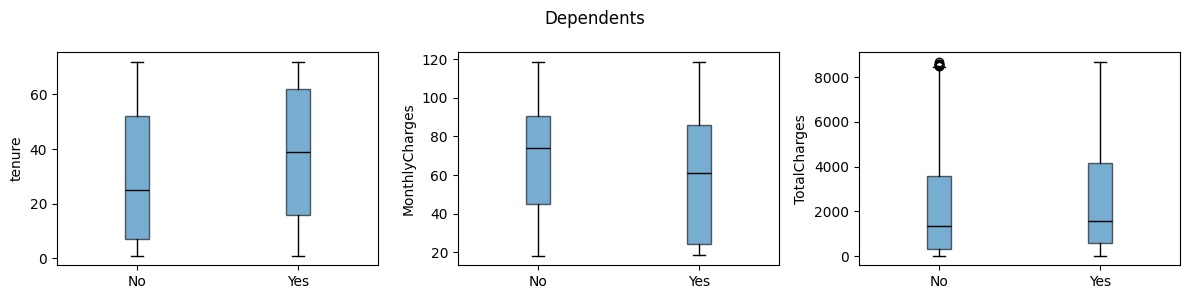

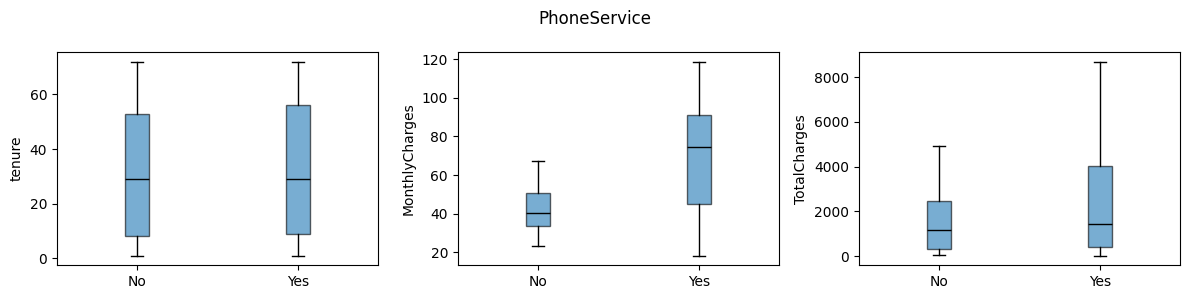

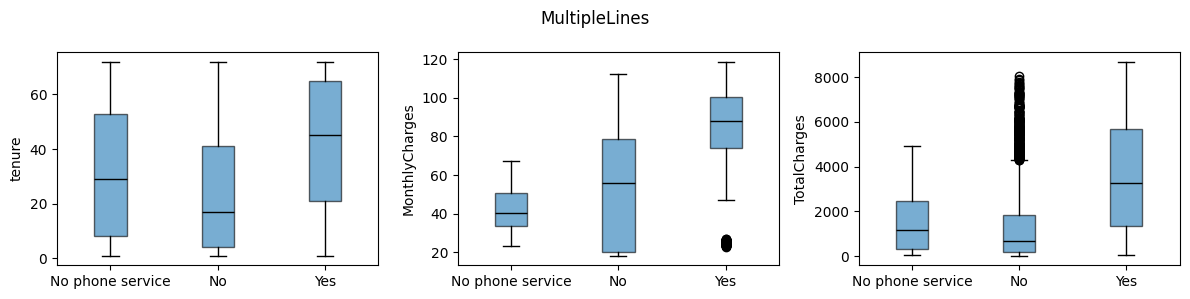

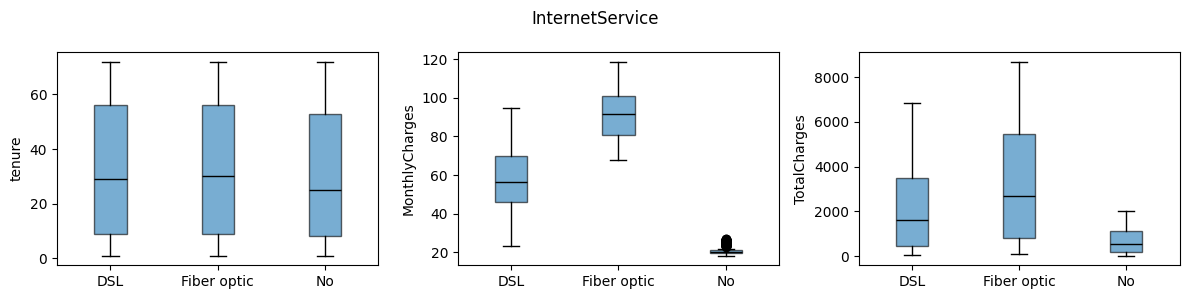

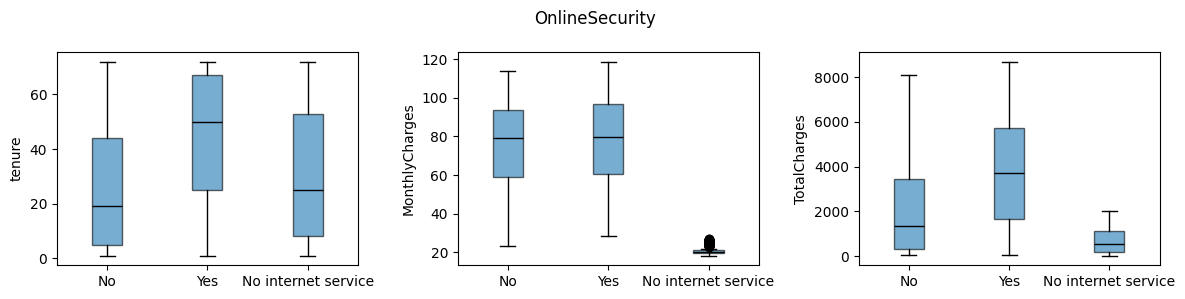

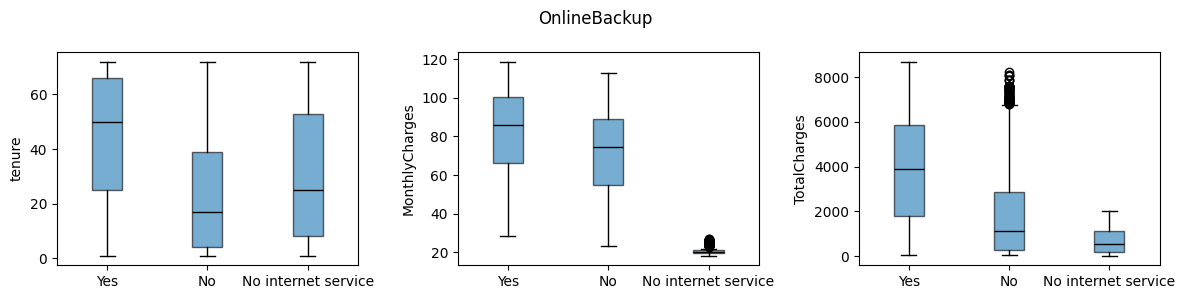

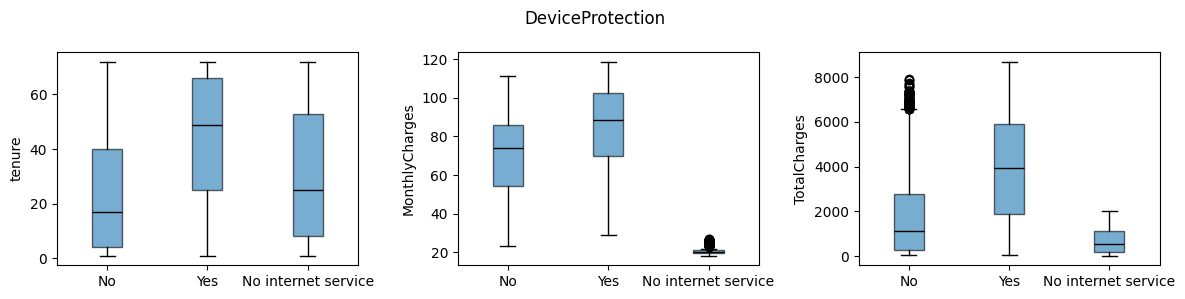

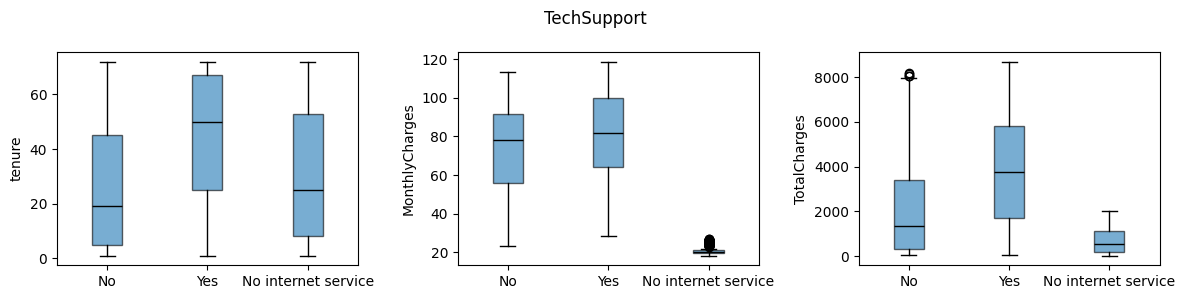

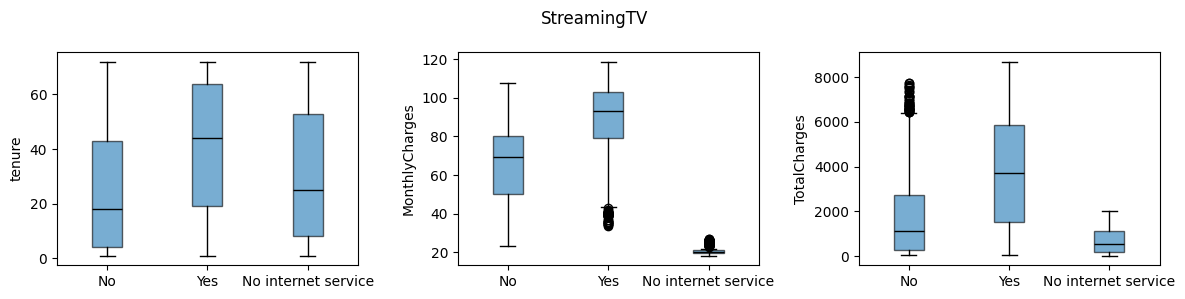

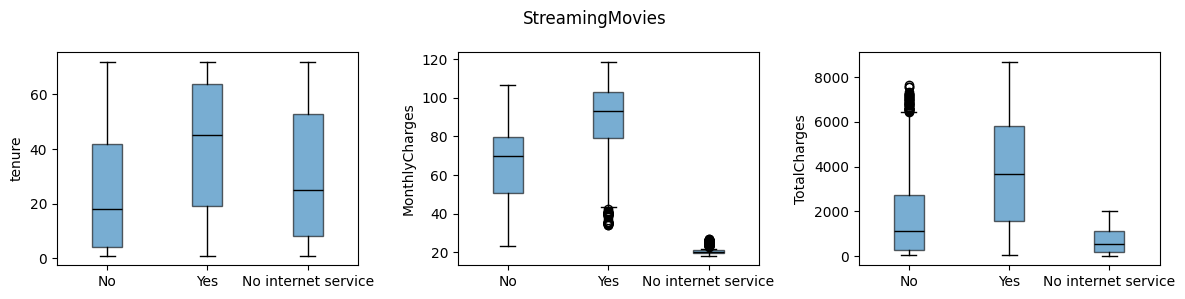

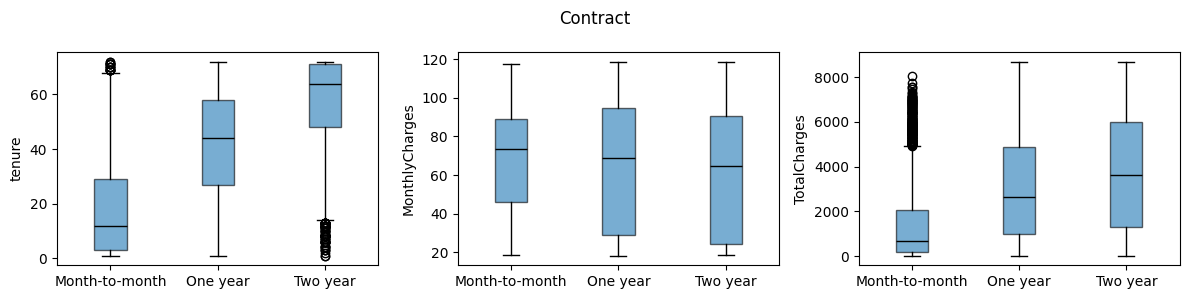

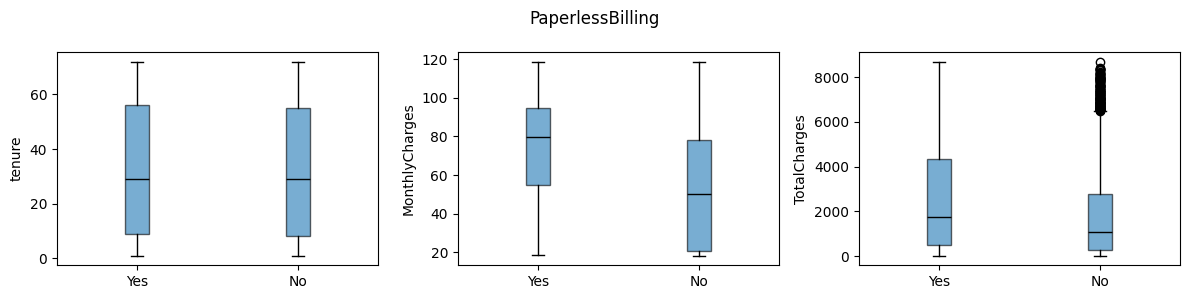

In [83]:
for col in categorical_features[:-1]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
    for i in range(len(numerical_features)):
        axs[i].boxplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                   patch_artist=True, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],labels=cat_values)
    fig.suptitle(col)

    plt.tight_layout()
    plt.show()

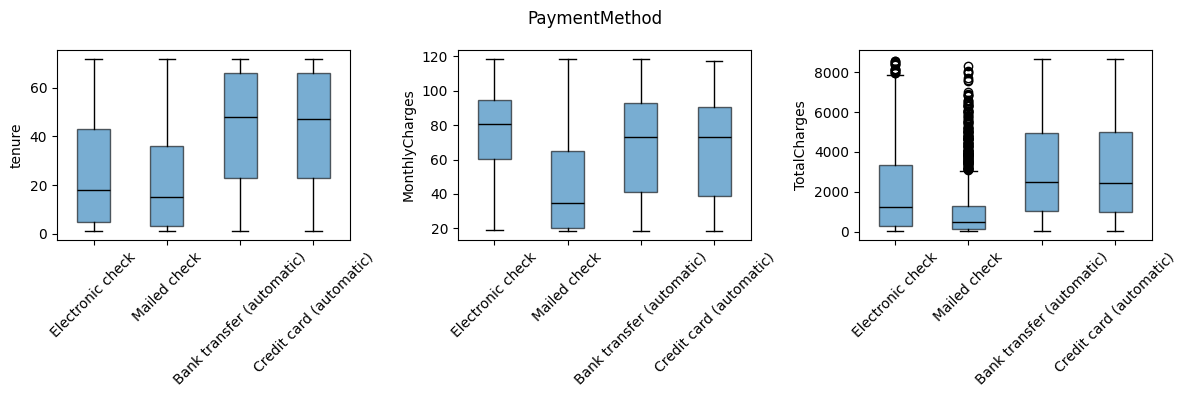

In [84]:
for col in categorical_features[-1:]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,4))
    for i in range(len(numerical_features)):
        axs[i].boxplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                   patch_artist=True, 
                   boxprops={'facecolor': 'C0', 'alpha' : 0.6},
                   medianprops={'color': 'black'})
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))], labels=cat_values)
        if col == 'PaymentMethod':
            axs[i].tick_params(axis='x', rotation=45)
    fig.suptitle(col)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

#### Violinplot per Categorical Feature

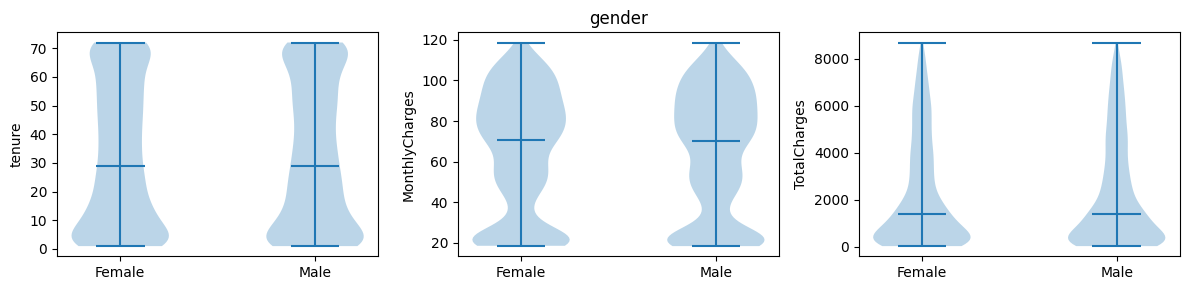

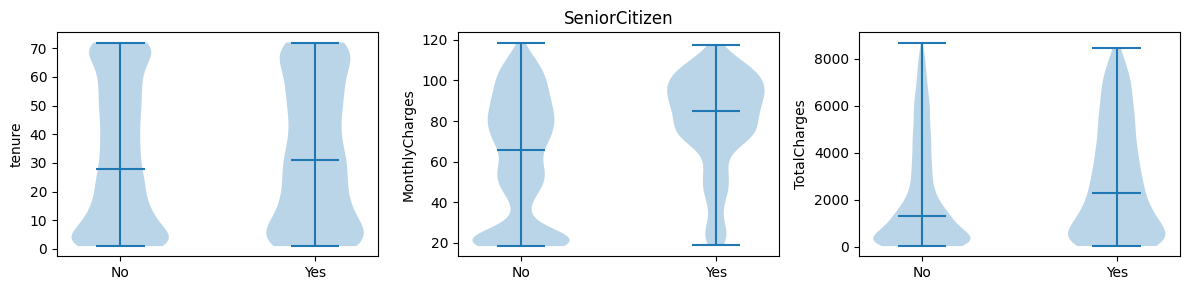

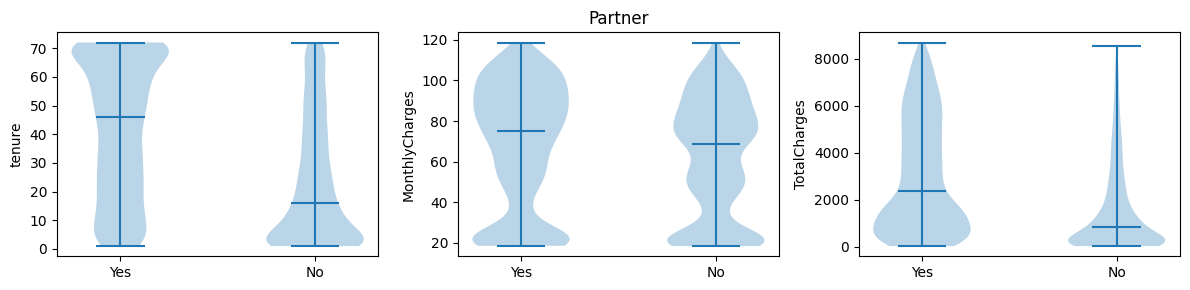

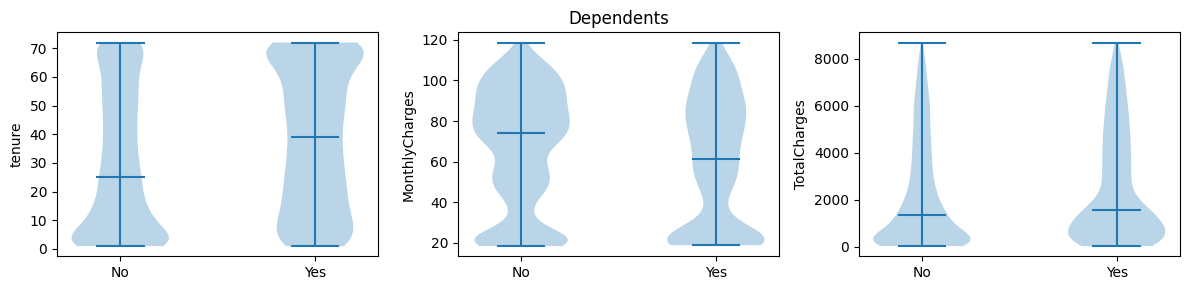

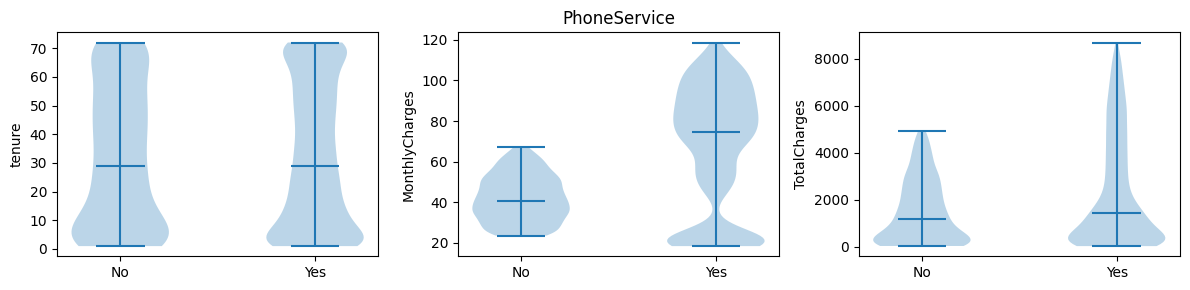

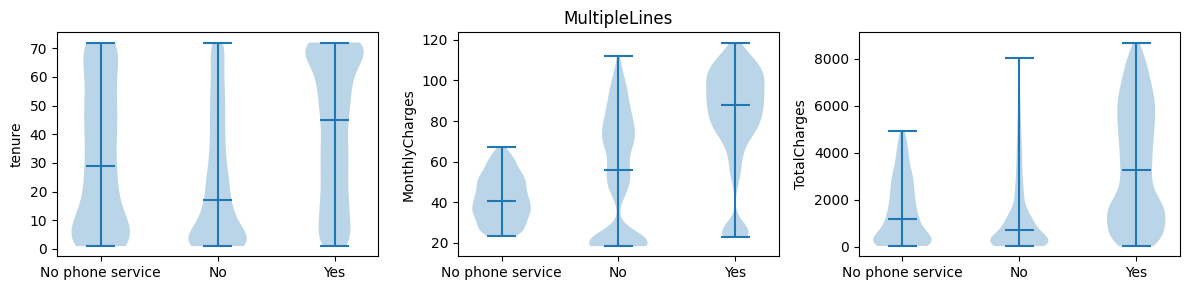

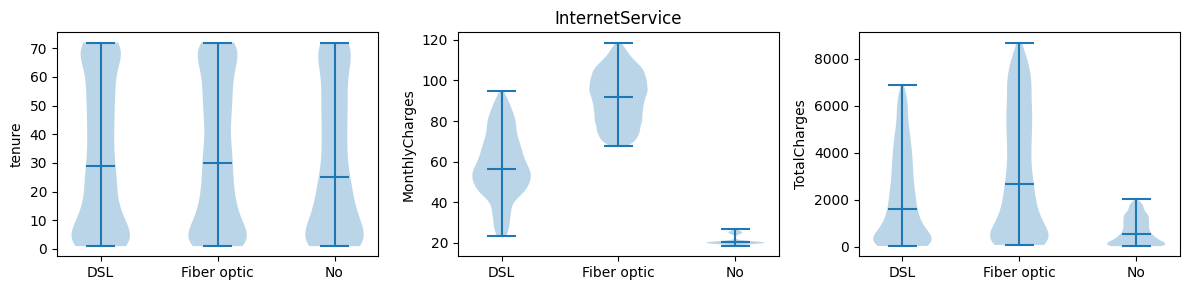

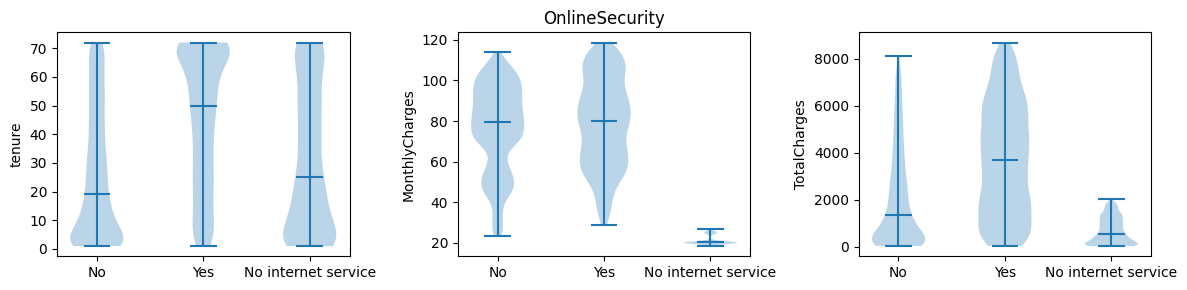

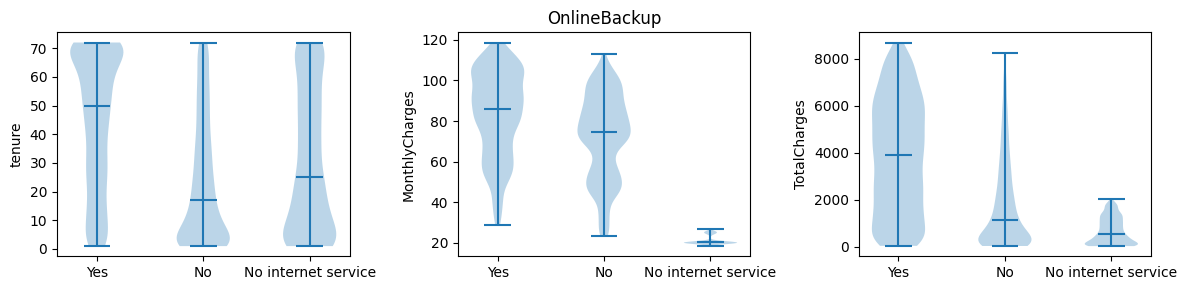

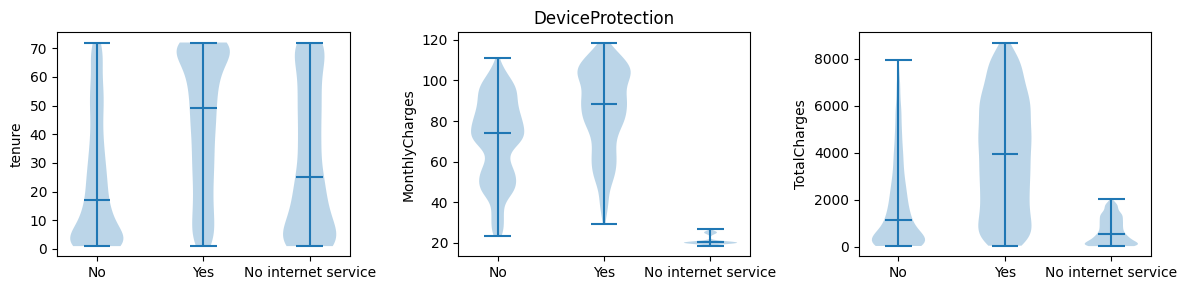

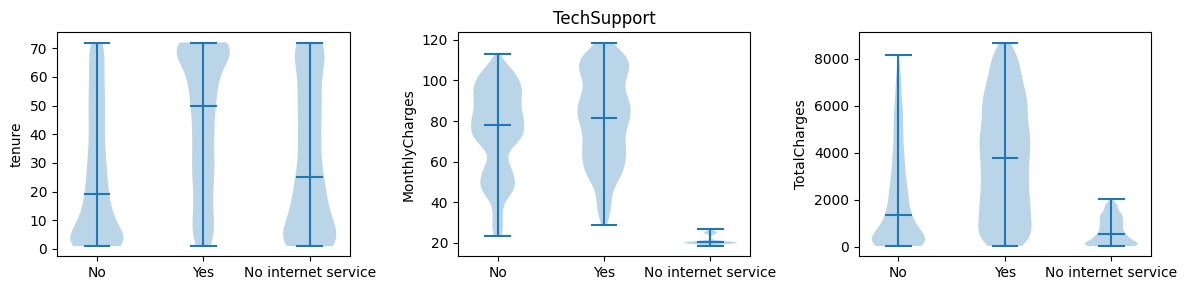

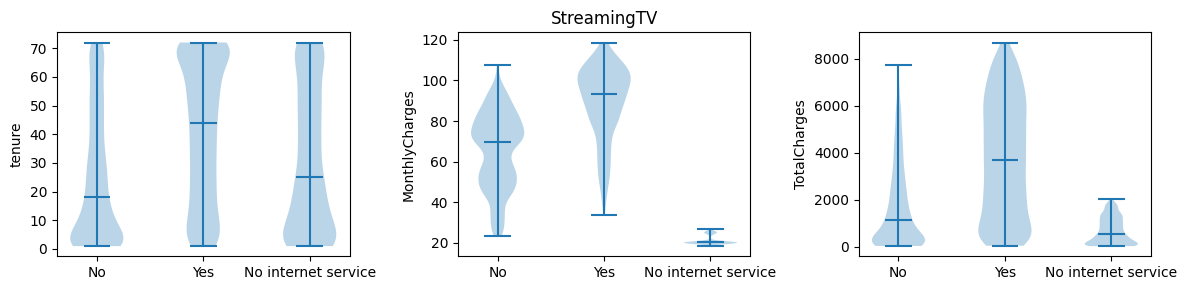

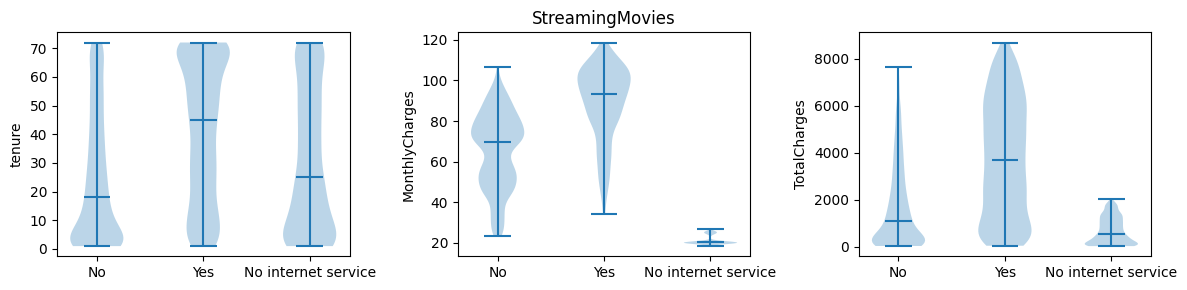

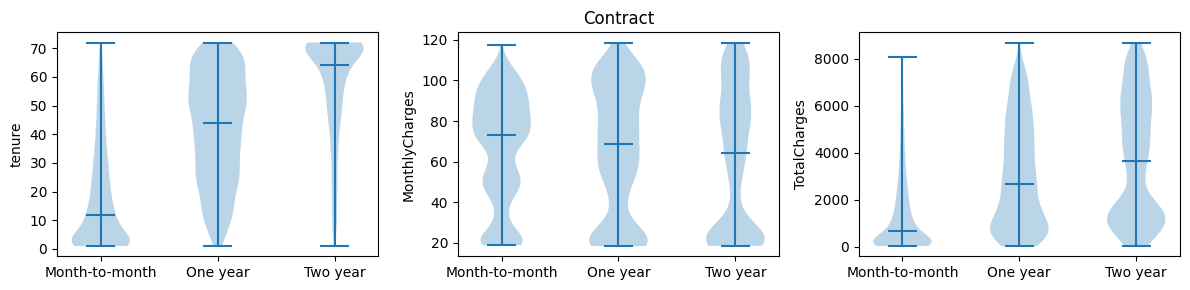

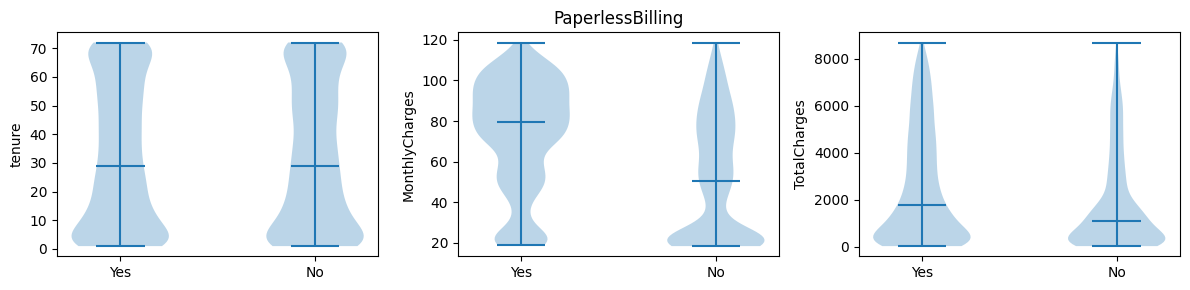

In [85]:
for col in categorical_features[:-1]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,3))
    for i in range(len(numerical_features)):
        axs[i].violinplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                  showmeans=False,showmedians=True)
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],
                  labels=cat_values)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

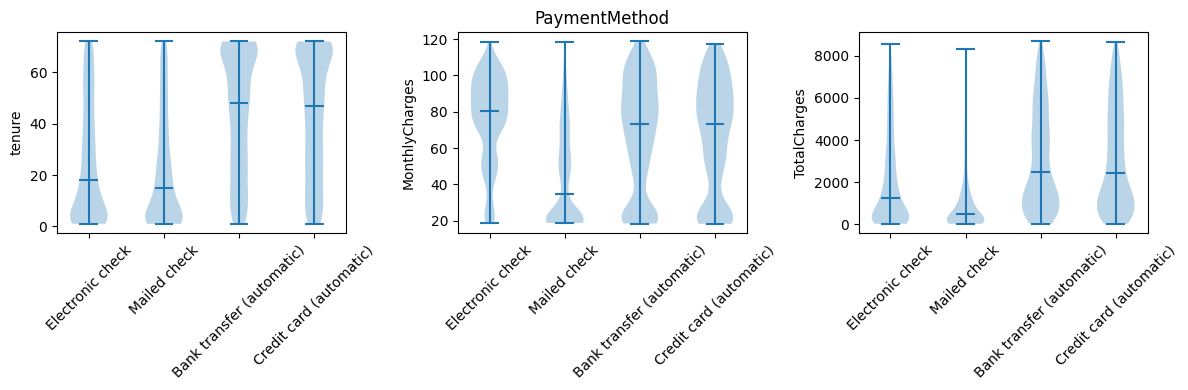

In [86]:
for col in categorical_features[-1:]:
    cat_values = df[col].unique()
    fig, axs = plt.subplots(1,len(numerical_features), figsize = (12,4))
    for i in range(len(numerical_features)):
        axs[i].violinplot([df[df[col]==cat_value][numerical_features[i]] for cat_value in cat_values],
                  showmeans=False,showmedians=True)
        axs[i].set_ylabel(numerical_features[i])
        axs[i].set_xticks([y + 1 for y in range(len(cat_values))],
                  labels=cat_values)
        if col == 'PaymentMethod':
            axs[i].tick_params(axis='x', rotation=45)
    axs[1].set_title(col)

    plt.tight_layout()
    plt.show()

#### Summary:

- Senior Citizens -> Higher monthly and total charges
- No partner -> Lower total charges and shorter tenure
- With dependents -> Longer tenure
- No phone service -> Lower monthly and total charges
- With multiple lines -> Longer tenure, higher monthly and total charges
- No internet -> Lower monthly and total charges
- Fiber optics -> Higher monthly charges
- With online security, online backup, device protection, tech support, streaming TV, streaming movies -> Longer tenure, higher monthly and total charges
- Two year contract -> Longer tenure, higher total charges
- Month-to-month contract -> Shorter tenure, lower total charges
- Paperless billing -> Higher monthly and total charges

#### Histograms

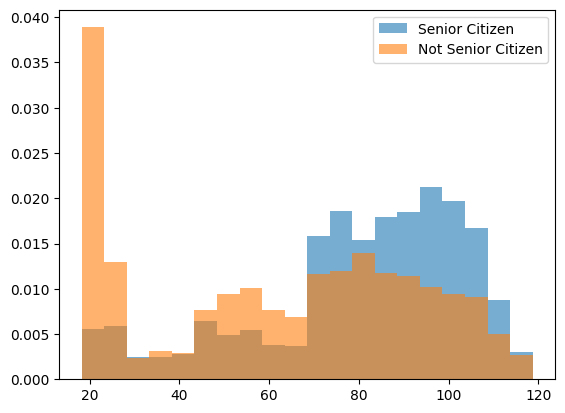

In [87]:
counts, bins=np.histogram(df["MonthlyCharges"],bins=20)
plt.hist(df[df["SeniorCitizen"]=="Yes"]["MonthlyCharges"],bins=bins,density=True,alpha=0.6,label="Senior Citizen")
plt.hist(df[df["SeniorCitizen"]=="No"]["MonthlyCharges"],bins=bins,density=True,alpha=0.6,label="Not Senior Citizen")
plt.legend();

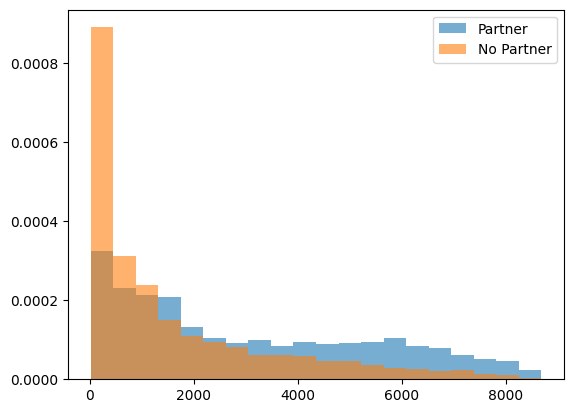

In [88]:
counts, bins=np.histogram(df["TotalCharges"],bins=20)
plt.hist(df[df["Partner"]=="Yes"]["TotalCharges"],bins=bins,density=True,alpha=0.6,label="Partner")
plt.hist(df[df["Partner"]=="No"]["TotalCharges"],bins=bins,density=True,alpha=0.6,label="No Partner")
plt.legend();

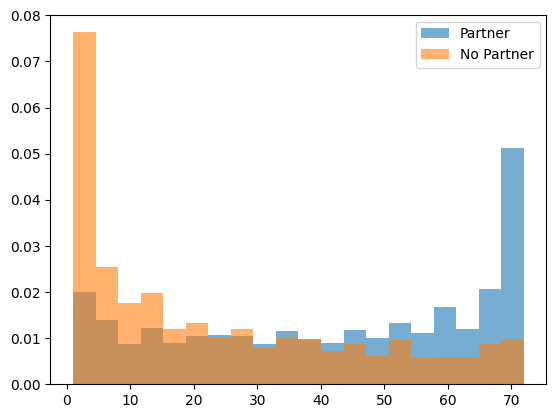

In [89]:
counts, bins=np.histogram(df["tenure"],bins=20)
plt.hist(df[df["Partner"]=="Yes"]["tenure"],bins=bins,density=True,alpha=0.6,label="Partner")
plt.hist(df[df["Partner"]=="No"]["tenure"],bins=bins,density=True,alpha=0.6,label="No Partner")
plt.legend();